# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
df = pd.read_csv('../data/checker_submits.csv')

In [3]:
df

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104
...,...,...,...,...
1681,user_19,laba06s,9,2020-05-21 20:01:48.959966
1682,user_1,laba06s,6,2020-05-21 20:18:54.487900
1683,user_1,laba06s,7,2020-05-21 20:19:06.872761
1684,user_1,laba06s,8,2020-05-21 20:22:41.877806


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df.drop(['timestamp'], axis=1)
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [5]:
categorical_features = ['uid', 'labname']  
numerical_features = ['numTrials', 'hour']  

X = df[categorical_features + numerical_features]
y = df['dayofweek']

In [6]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [7]:
X_category_encoded = ohe.fit_transform(X[categorical_features])
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

In [8]:
df_categorical = pd.DataFrame(
    X_category_encoded, 
    columns=encoded_feature_names,
    index=X.index
)
df_categorical

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
scaler = StandardScaler()

X_numerical_scaled = scaler.fit_transform(X[numerical_features])

In [10]:
df_numerical = pd.DataFrame(
    X_numerical_scaled,
    columns=numerical_features,
    index=X.index
)
df_numerical

,numTrials,hour
0,-0.788667,-2.562352
1,-0.756764,-2.562352
2,-0.724861,-2.562352
3,-0.692958,-2.562352
4,-0.661055,-2.562352
...,...,...
1681,-0.533442,0.945382
1682,-0.629151,0.945382
1683,-0.597248,0.945382
1684,-0.565345,0.945382


In [11]:
df = pd.concat([df_categorical, df_numerical], axis=1)
df

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,numTrials,hour
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.788667,-2.562352
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.756764,-2.562352
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.724861,-2.562352
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.692958,-2.562352
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.661055,-2.562352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.533442,0.945382
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.629151,0.945382
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.597248,0.945382
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.565345,0.945382


In [38]:
df['dayofweek'] = y.values
df.to_csv('../data/dayofweek.csv', index=False)
df


,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,numTrials,hour,dayofweek
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.788667,-2.562352,4
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.756764,-2.562352,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.724861,-2.562352,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.692958,-2.562352,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.661055,-2.562352,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.533442,0.945382,3
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.629151,0.945382,3
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.597248,0.945382,3
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.565345,0.945382,3


In [37]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']
more = np.array([np.argmax(np.bincount(y))] * len(y))
accuracy_score(y, more)

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [14]:
def plot_features(coefs, features, n=10):
    fig, ax = plt.subplots(figsize=(15, 8)) # определяем параметры графика
    indices = coefs.argsort()[::-1][:n] # индексами берем фичи (аргументы коэффициентов регрессии), отсортированные по возрастанию, поэтому срез с конца, последние n
    ax.barh(np.arange(n), coefs[indices])
    ax.set_yticks(np.arange(n))
    ax.set_yticklabels(features[indices])
    ax.invert_yaxis() # сделаем, чтобы более значимые фичи были сверху
    plt.show()

In [32]:
baseline_model = LogisticRegression(random_state=21, fit_intercept=False, max_iter=2000, solver='lbfgs')
baseline_model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [33]:
y_pred = baseline_model.predict(X)
accuracy = accuracy_score(y_pred, y)
accuracy

0.6405693950177936

In [34]:
feature_importance = np.sum(np.abs(baseline_model.coef_), axis=0)

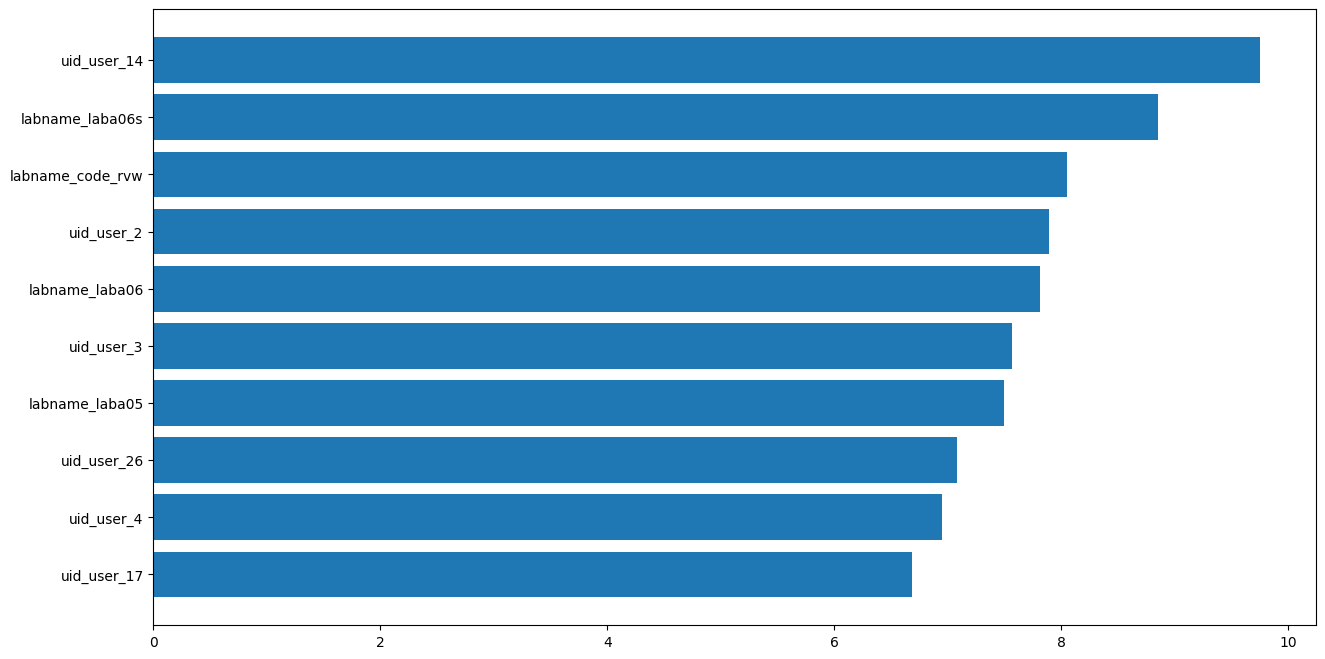

In [35]:
plot_features(feature_importance, X.columns, n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [19]:
svc_model = SVC(kernel='linear', probability=True, random_state=21 )
svc_model.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
pred_y = svc_model.predict(X)
accuracy_score(y, pred_y)

0.702846975088968

In [21]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=21)
    svm.fit(X, y)
    
    y_pred = svm.predict(X)
    acc = accuracy_score(y, y_pred)
       
    print(f"{kernel}: accuracy = {acc:.3f}")

linear: accuracy = 0.703
poly: accuracy = 0.859
rbf: accuracy = 0.856
sigmoid: accuracy = 0.400


In [22]:
baseline_svc = OneVsRestClassifier(
    SVC(kernel='linear', probability=True, random_state=21)
)
baseline_svc.fit(X, y)
pred = baseline_svc.predict(X)
accuracy_score(y, pred)

0.6120996441281139

In [23]:
coefs = []
for estimator in baseline_svc.estimators_:
    coefs.append(estimator.coef_[0])
coef_matrix = np.array(coefs)
importance = np.sum(np.abs(coef_matrix), axis=0)

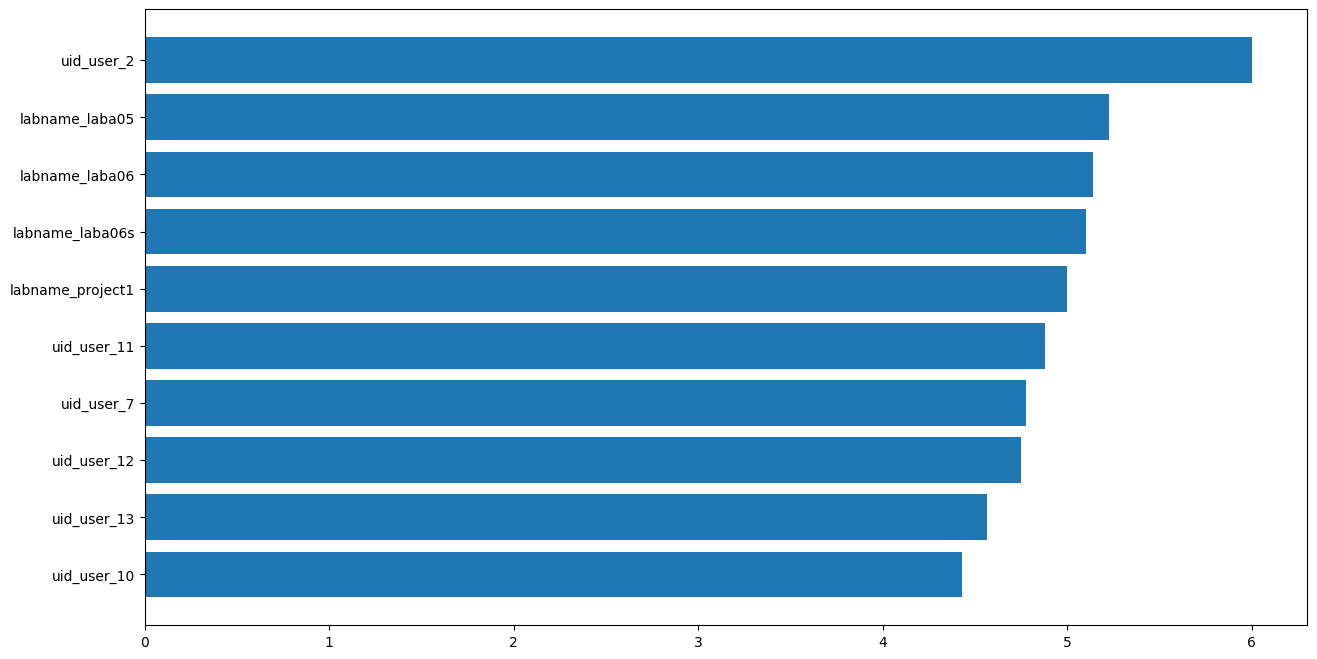

In [24]:
top_features = plot_features(importance, X.columns)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [25]:
baseline_tree = DecisionTreeClassifier(max_depth=4, random_state=21)
baseline_tree.fit(X, y)

y_tree = baseline_tree.predict(X)

accuracy_score(y, y_tree)

0.5516014234875445

In [26]:
for depth in range(1, 20, 2):
    model_tree = DecisionTreeClassifier(max_depth=depth, random_state=21)
    model_tree.fit(X, y)
    y_tree = model_tree.predict(X)
    acc = accuracy_score(y, y_tree)
    print(f'Accuracy = {acc:.4f} for depth {depth}')

Accuracy = 0.3577 for depth 1
Accuracy = 0.4899 for depth 3
Accuracy = 0.6109 for depth 5
Accuracy = 0.7064 for depth 7
Accuracy = 0.7847 for depth 9
Accuracy = 0.8499 for depth 11
Accuracy = 0.9104 for depth 13
Accuracy = 0.9460 for depth 15
Accuracy = 0.9709 for depth 17
Accuracy = 0.9840 for depth 19


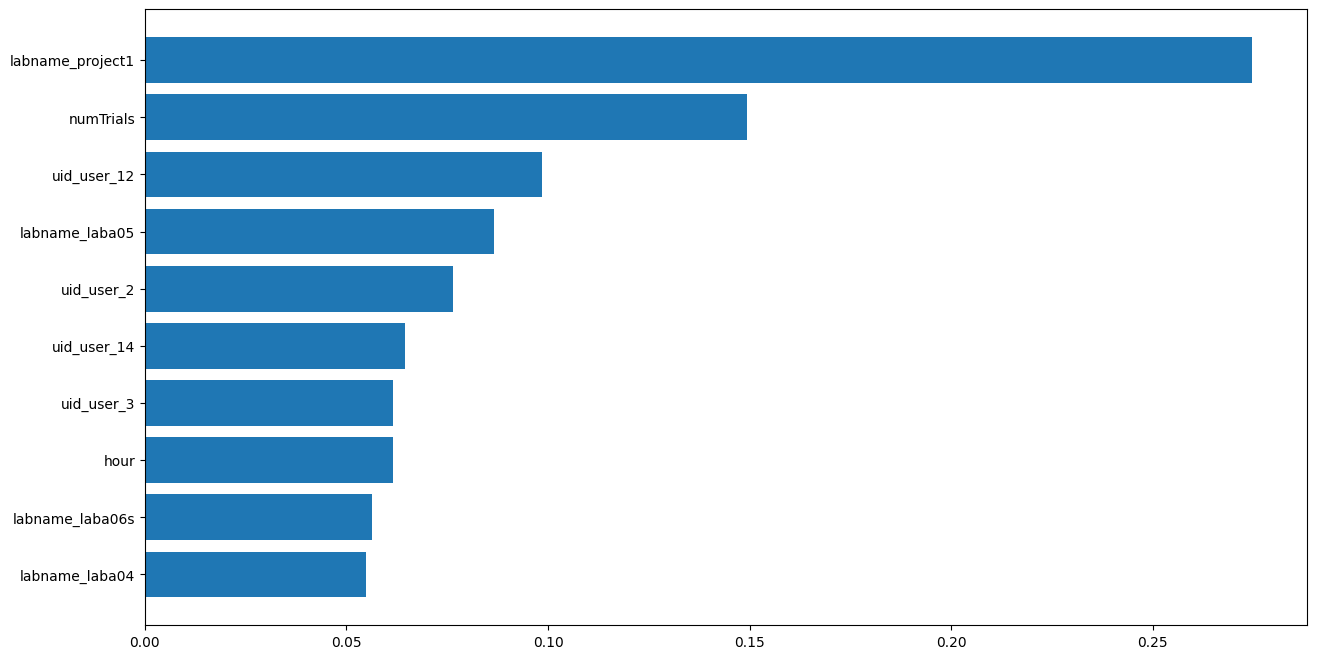

In [27]:
top_features = plot_features(baseline_tree.feature_importances_, X.columns)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [28]:
baseline_forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
baseline_forest.fit(X, y)
y_pred = baseline_forest.predict(X)
accuracy_score(y, y_pred)

0.9988137603795967

In [29]:
for depth in range(5, 26, 5):
    for estimators in range(50, 101, 50):
        model_forest = RandomForestClassifier(n_estimators=estimators, max_depth=depth, random_state=21)
        model_forest.fit(X, y)
        y_f = model_forest.predict(X)
        score = accuracy_score(y, y_f)
        print(f'Score = {score:.4f} for depth = {depth} and estimators = {estimators}')
    print('-' * 50)

Score = 0.6198 for depth = 5 and estimators = 50
Score = 0.6429 for depth = 5 and estimators = 100
--------------------------------------------------
Score = 0.8796 for depth = 10 and estimators = 50
Score = 0.8701 for depth = 10 and estimators = 100
--------------------------------------------------
Score = 0.9798 for depth = 15 and estimators = 50
Score = 0.9804 for depth = 15 and estimators = 100
--------------------------------------------------
Score = 0.9976 for depth = 20 and estimators = 50
Score = 0.9976 for depth = 20 and estimators = 100
--------------------------------------------------
Score = 0.9994 for depth = 25 and estimators = 50
Score = 0.9988 for depth = 25 and estimators = 100
--------------------------------------------------


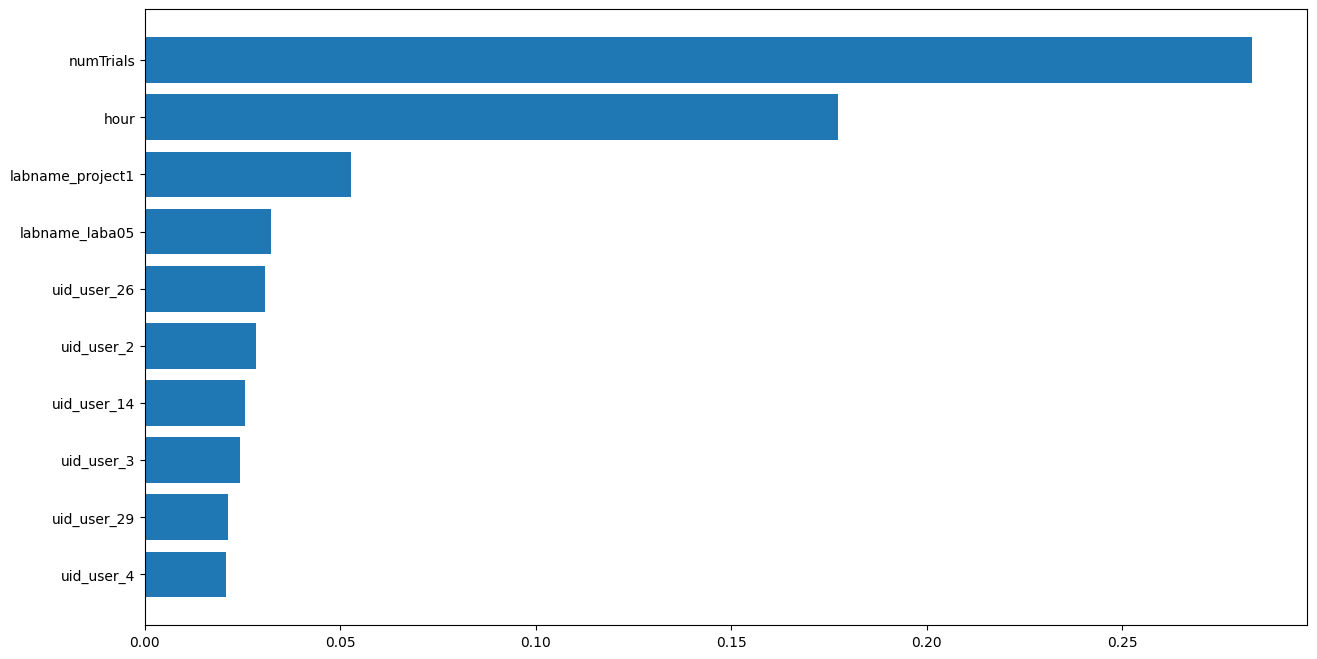

In [30]:
top_features = plot_features(baseline_forest.feature_importances_, X.columns)